In [1]:
!pip install kagglehub

In [3]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
import kagglehub
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
print(path)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
/kaggle/input/smoke-fire-detection-yolo


In [5]:
!ls /kaggle/input/smoke-fire-detection-yolo

data  data.yaml


In [6]:
!cat /kaggle/input/smoke-fire-detection-yolo/data.yaml

path: /kaggle/working/D Fire Dataset  # dataset root dir
train: data/train/images  # train images (relative to 'path')
val: data/val/images  # val images (relative to 'path')
test: data/test/images  # test images (relative to 'path')

# Classes
names: ['smoke', 'fire']  # Replace with your actual class names

# Counts
nc: 2  # number of classes
train_count: 14122
val_count: 3099
test_count: 4306


In [7]:
!ls /kaggle/input/smoke-fire-detection-yolo/data

test  train  val


In [8]:
yaml_content = """path: /kaggle/input/smoke-fire-detection-yolo/data
train: train/images
val: val/images
test: test/images

names: ['smoke', 'fire']
nc: 2
"""

with open('/content/data.yaml', 'w') as f:
    f.write(yaml_content)

print(yaml_content)

path: /kaggle/input/smoke-fire-detection-yolo/data
train: train/images
val: val/images
test: test/images

names: ['smoke', 'fire']
nc: 2



In [9]:
!ls /kaggle/input/smoke-fire-detection-yolo/data


test  train  val


In [10]:
!ls /kaggle/input/smoke-fire-detection-yolo/data/train

images	labels


In [11]:
!pip install ultralytics -q

from ultralytics import YOLO

# Load a small pretrained YOLOv8 model as your starting point
model = YOLO('yolov8n.pt')

# Toy run first — just 10 epochs to confirm everything works end-to-end
results = model.train(
    data='/content/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    name='fire_smoke_toy_run'
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 6.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deter

In [12]:
model = YOLO('/content/runs/detect/fire_smoke_toy_run/weights/best.pt')
results = model.predict('/kaggle/input/smoke-fire-detection-yolo/data/test/images', save=True, conf=0.4)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06723.jpg: 384x640 (no detections), 10.9ms
image 2/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06724.jpg: 352x640 (no detections), 42.1ms
image 3/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06725.jpg: 384x640 (no detections), 7.1ms
image 4/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06726.jpg: 384x640 (no detections), 6.3

In [13]:
from ultralytics import YOLO
from IPython.display import Image, display

model = YOLO('/content/runs/detect/fire_smoke_toy_run/weights/best.pt')

results = model.predict(
    '/kaggle/input/smoke-fire-detection-yolo/data/test/images',
    conf=0.4,
    save=False,   # don't save all 4306, we'll just inspect
    stream=True   # process one at a time, memory-efficient
)

count = 0
for r in results:
    if len(r.boxes) > 0:   # only images where something was actually detected
        r.save(filename=f'/content/detected_{count}.jpg')
        count += 1
        if count >= 6:  # stop after finding 6 examples
            break

print(f"Found {count} images with detections")


image 1/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06723.jpg: 384x640 (no detections), 6.0ms
image 2/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06724.jpg: 352x640 (no detections), 7.2ms
image 3/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06725.jpg: 384x640 (no detections), 6.9ms
image 4/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06726.jpg: 384x640 (no detections), 6.0ms
image 5/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06727.jpg: 384x640 (no detections), 6.3ms
image 6/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06728.jpg: 384x640 (no detections), 6.1ms
image 7/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06729.jpg: 384x640 (no detections), 11.4ms
image 8/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06730.jpg: 384x640 (no detections), 6.1ms
image 9/4306 /kaggle/input/smoke-fire-detection-yolo/data/test/images/AoF06731

In [15]:
from google.colab import files
files.download('/content/runs/detect/fire_smoke_toy_run/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

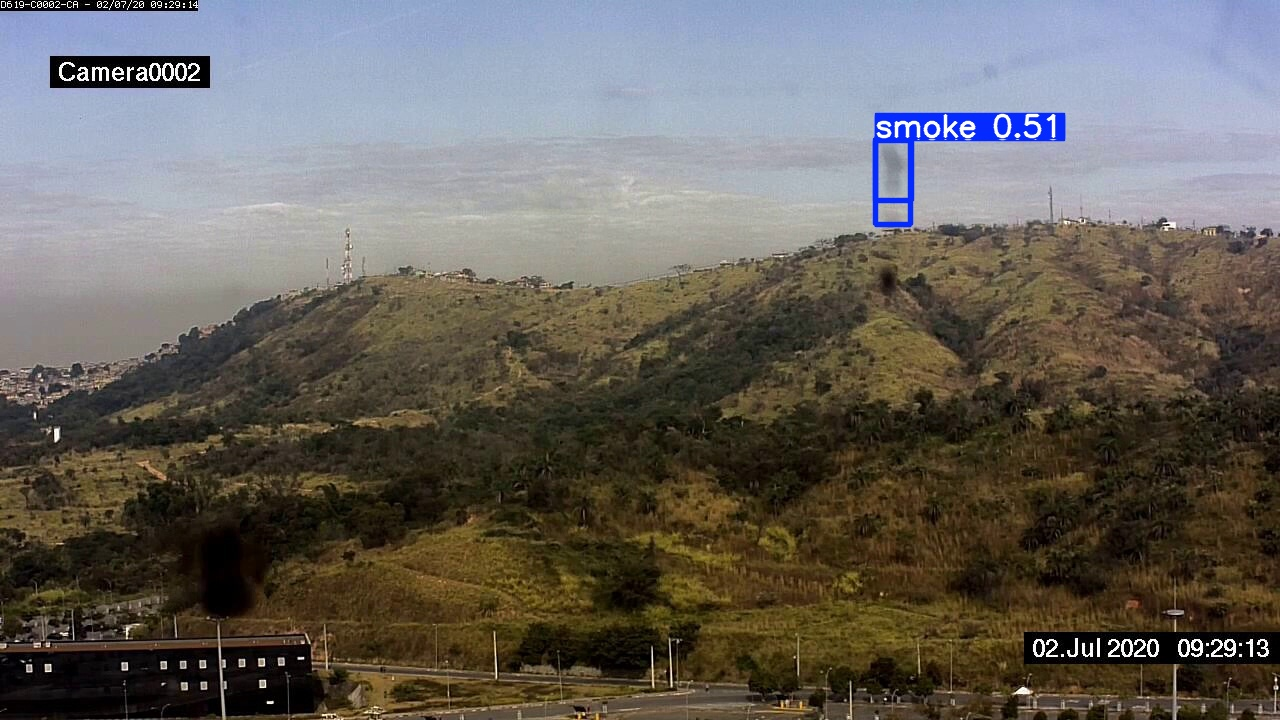

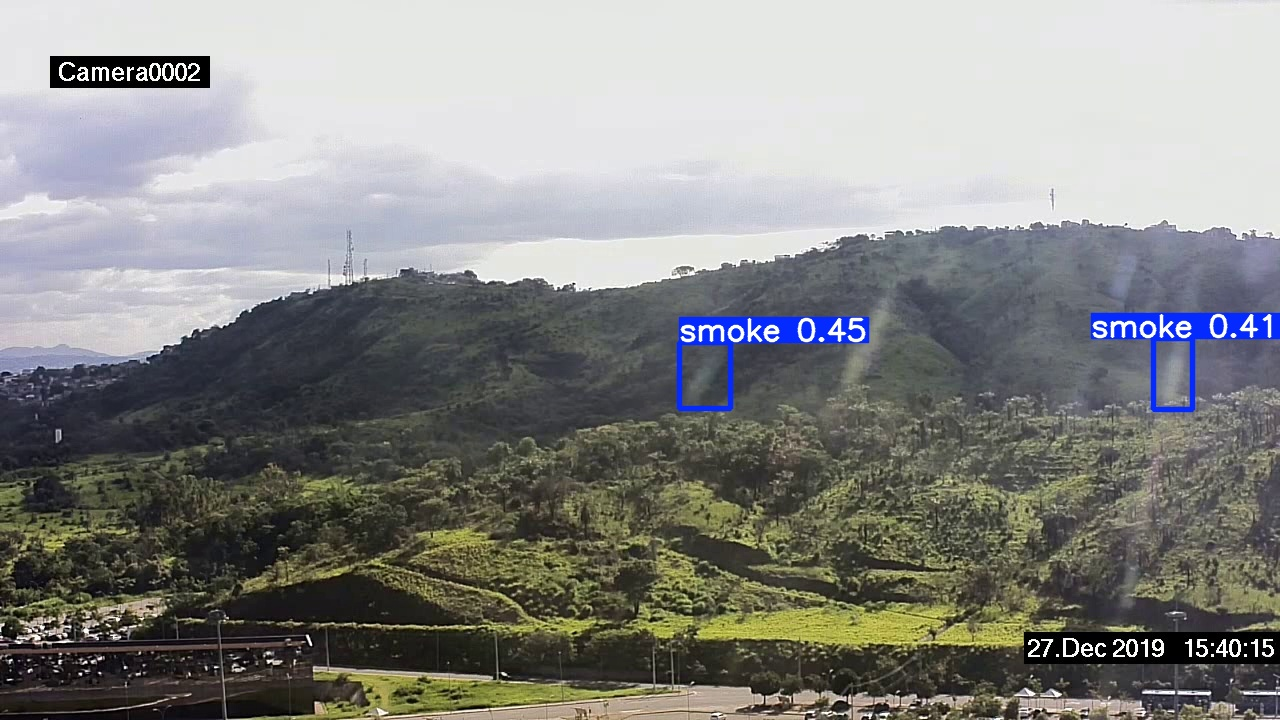

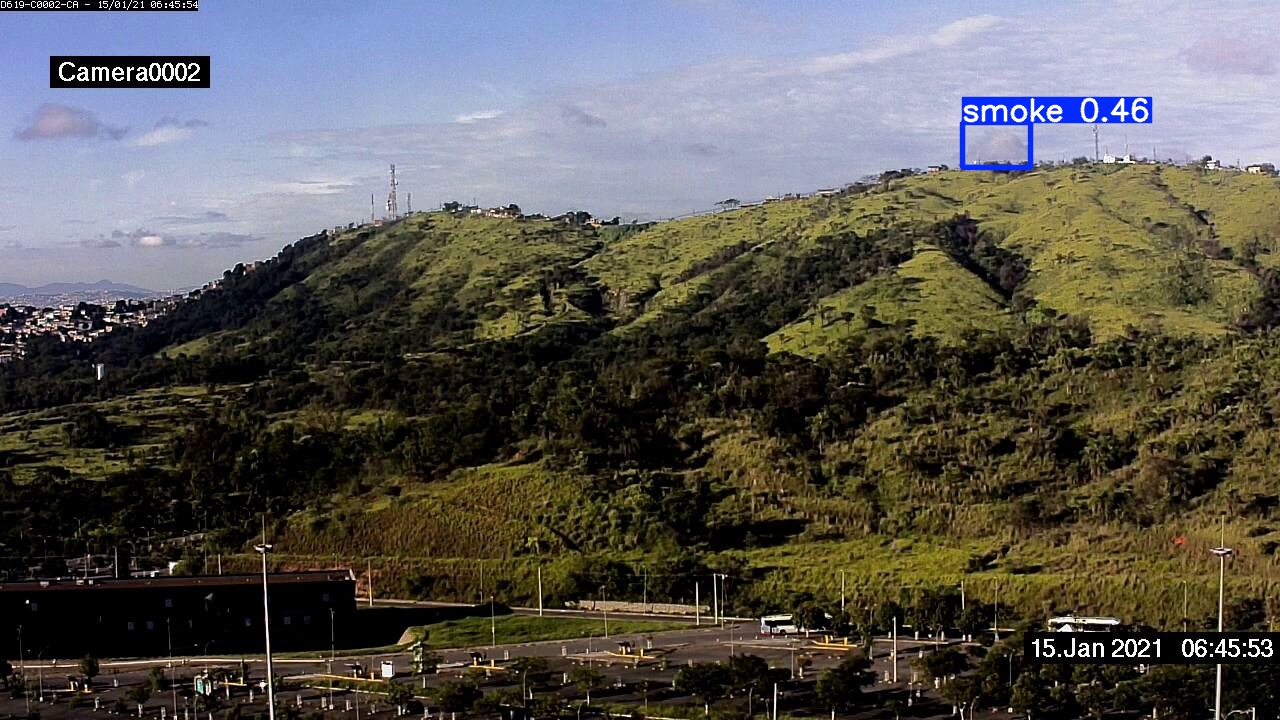

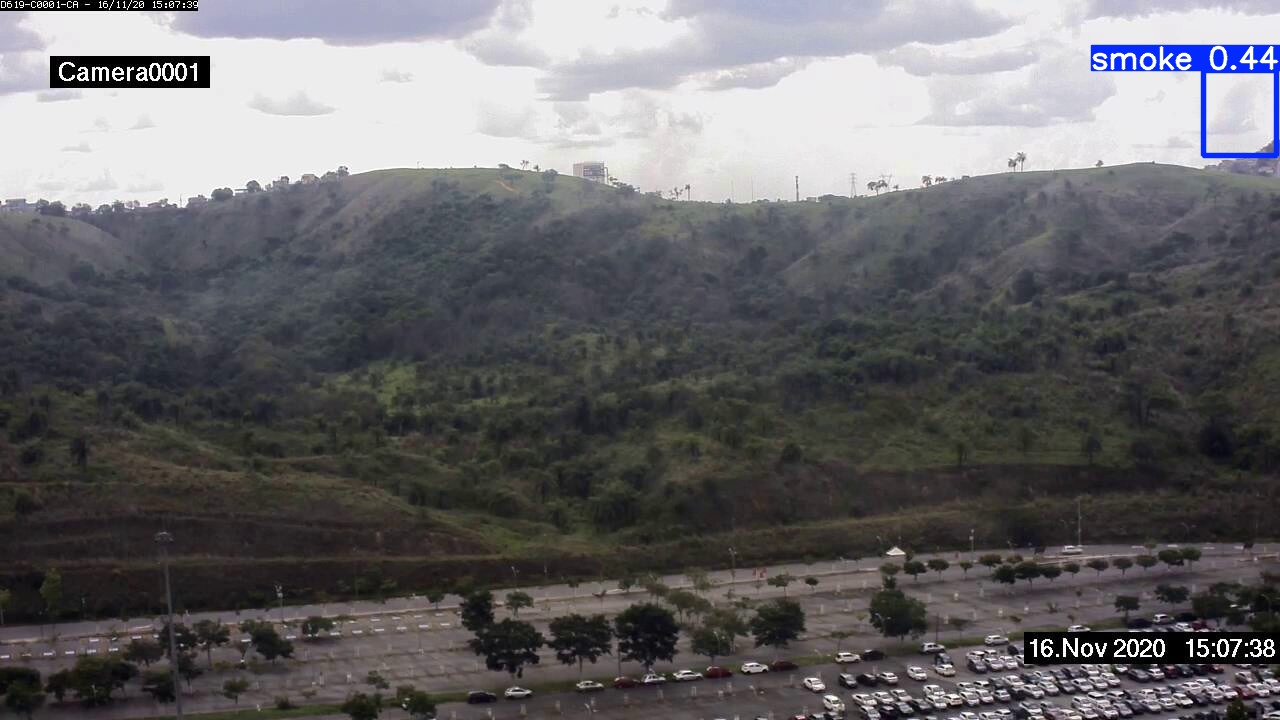

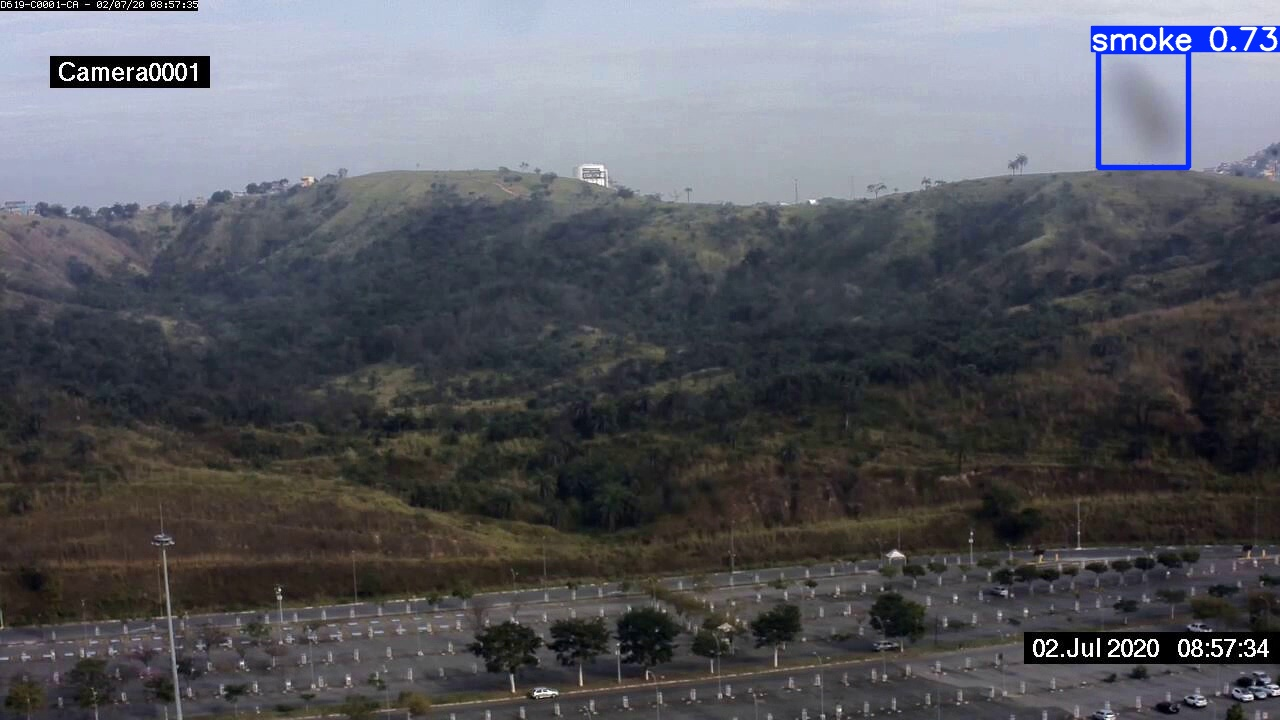

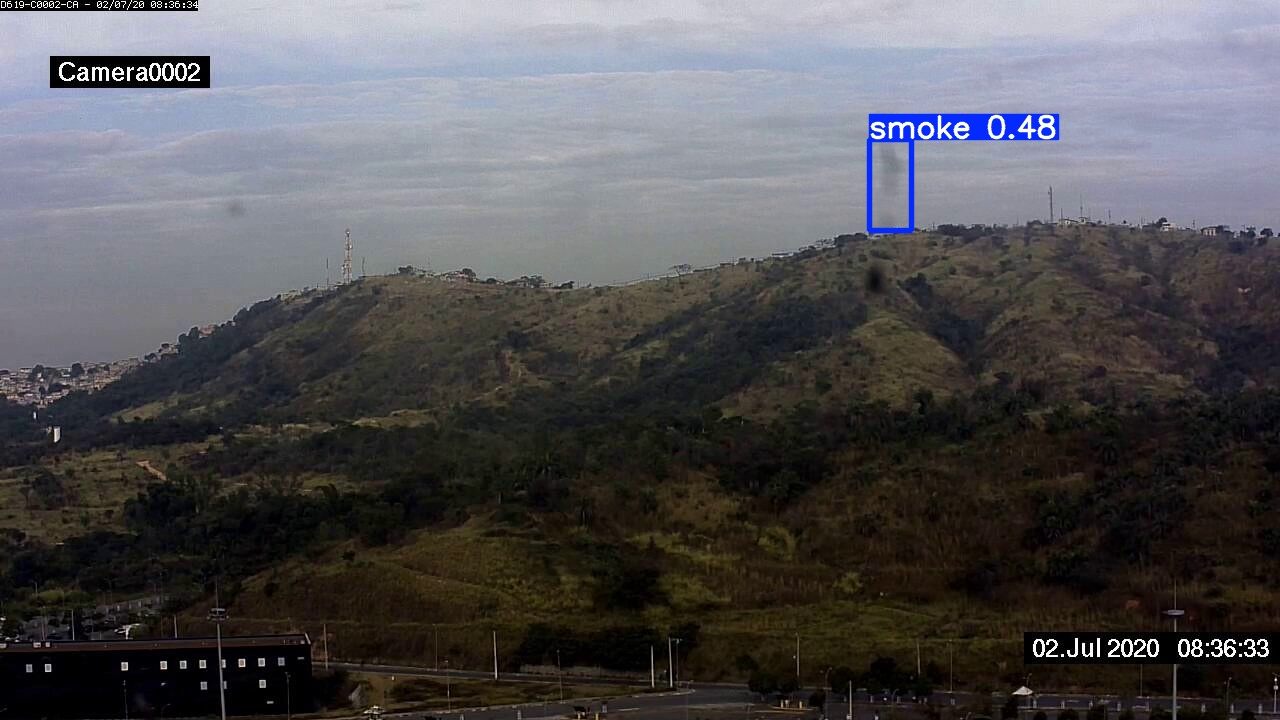

In [14]:
import glob
for img_path in glob.glob('/content/detected_*.jpg'):
    display(Image(filename=img_path))